## 0 · Environment Setup
Installs required packages, sets up seeds for reproducibility, and detects the target device.

In [10]:
import sys
import os
import subprocess
try:
    import transformers
    import imblearn
    import wordcloud
    import arabic_reshaper
    import bidi
    import pandarallel
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", 
                           "transformers", "scikit-learn", "imbalanced-learn", 
                           "pandas", "numpy", "matplotlib", "seaborn", 
                           "wordcloud", "arabic-reshaper", "python-bidi", 
                           "tqdm", "pandarallel"])

import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
from tqdm.auto import tqdm
import gc
from IPython.display import display

# Set seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Define directory structure
BASE_DIR = '..'
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
IMAGE_DIR = os.path.join(OUTPUT_DIR, 'images')
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
RESULT_DIR = os.path.join(OUTPUT_DIR, 'results')
DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
RAW_DATA_DIR = os.path.join(DATASET_DIR, 'raw')
LABELED_DATA_DIR = os.path.join(DATASET_DIR, 'labeled')
PROCESSED_DATA_DIR = os.path.join(DATASET_DIR, 'processed')

# Create directories if they don't exist
for d in [IMAGE_DIR, MODEL_DIR, RESULT_DIR, RAW_DATA_DIR, LABELED_DATA_DIR, PROCESSED_DATA_DIR]:
    os.makedirs(d, exist_ok=True)


Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti


## 1 · Data Loading
Loads the dataset in chunks to handle memory safely, extracts labelled rows, and caches them.

In [11]:
from IPython.display import display
import os

# Preference: dataset/full_dataset.json -> dataset/full_dataset.csv -> dataset_v2.csv
json_path = os.path.join(LABELED_DATA_DIR, 'full_dataset.json')
csv_path = os.path.join(LABELED_DATA_DIR, 'full_dataset.csv')
v2_path = os.path.join(PROCESSED_DATA_DIR, 'dataset_v2.csv')

# Check if dataset is in parent directory
if not os.path.exists(json_path) and os.path.exists('../dataset'):
    json_path = '../' + json_path
    csv_path = '../' + csv_path
    v2_path = '../dataset/dataset_v2.csv'
elif not os.path.exists(json_path) and os.path.exists('dataset/dataset_v2.csv'):
    v2_path = 'dataset/dataset_v2.csv'

df_labelled = pd.DataFrame()
total_rows = 0

if os.path.exists(json_path):
    print(f"Loading from {json_path}...")
    df_all = pd.read_json(json_path)
    total_rows = len(df_all)
    # In this dataset, labels are 0, 1. -1 represents errors or unlabeled.
    df_labelled = df_all[df_all['label'].isin([0, 1, 0.0, 1.0])].copy()
    # Ensure correct column names if they differ
    if 'comment_text' not in df_labelled.columns and 'text' in df_labelled.columns:
        df_labelled = df_labelled.rename(columns={'text': 'comment_text'})
elif os.path.exists(csv_path) or os.path.exists(v2_path):
    file_path = csv_path if os.path.exists(csv_path) else v2_path
    # Note: v2_path was prioritized in original code if it exists
    if os.path.exists(v2_path):
        file_path = v2_path
        
    print(f"Loading from {file_path}...")
    labelled_chunks = []
    chunksize = 50_000
    for chunk in pd.read_csv(file_path, chunksize=chunksize, engine='python', on_bad_lines='skip'):
        total_rows += len(chunk)
        
        # Auto-detect text column
        text_col = 'comment_text' if 'comment_text' in chunk.columns else ('text' if 'text' in chunk.columns else chunk.columns[0])
        # Auto-detect label column
        label_col = 'label' if 'label' in chunk.columns else ('Label' if 'Label' in chunk.columns else None)
        
        if label_col and label_col in chunk.columns:
            chunk = chunk.rename(columns={text_col: 'comment_text', label_col: 'label'})
            # Filter for valid labels 0 and 1
            labelled = chunk[chunk['label'].isin([0, 1, 0.0, 1.0])].dropna(subset=['label']).copy()
            labelled_chunks.append(labelled)

    if labelled_chunks:
        df_labelled = pd.concat(labelled_chunks, ignore_index=True)

if df_labelled.empty:
    print("Warning: No valid labeled data found. Using synthetic fallback for demonstration.")
    # Fallback if no labels exist: use a subset to pretend
    fallback_path = v2_path if os.path.exists(v2_path) else (csv_path if os.path.exists(csv_path) else None)
    if fallback_path:
        df_labelled = pd.read_csv(fallback_path, nrows=16000)
        text_col = 'text' if 'text' in df_labelled.columns else df_labelled.columns[0]
        df_labelled = df_labelled.rename(columns={text_col: 'comment_text'})
        df_labelled['label'] = np.random.choice([0, 1], len(df_labelled))
        if 'nationality' not in df_labelled.columns:
            df_labelled['nationality'] = np.random.choice(['Saudi Arabia', 'Egypt', 'Iraq', 'UAE'], len(df_labelled))
    else:
        # Minimal fallback
        df_labelled = pd.DataFrame({'comment_text': ['مثال نصي'], 'label': [1], 'nationality': ['Unknown']})

# Standardize labels to int
df_labelled['label'] = df_labelled['label'].astype(int)
# Remap labels for visualization
df_labelled['sentiment'] = df_labelled['label'].map({1: 'Positive', 0: 'Negative'})

print(f"Total rows scanned: {total_rows:,}")
print(f"Labelled count (0/1): {len(df_labelled):,}")
print(f"Columns: {df_labelled.columns.tolist()}")
print(f"Dtypes:\n{df_labelled.dtypes}")
print("\nFirst 5 rows:")
display(df_labelled.head())

# Save working copy for faster subsequent steps
df_labelled.to_pickle(os.path.join(PROCESSED_DATA_DIR, 'labelled_data.pkl'))
gc.collect()


Loading from ..\dataset\labeled\full_dataset.json...
Total rows scanned: 153,500
Labelled count (0/1): 135,875
Columns: ['comment_text', 'label', 'confidence', 'low_confidence', 'label_source', 'nationality', 'likes', 'csv_index', 'sentiment']
Dtypes:
comment_text          str
label               int64
confidence        float64
low_confidence       bool
label_source          str
nationality           str
likes               int64
csv_index           int64
sentiment             str
dtype: object

First 5 rows:


,comment_text,label,confidence,low_confidence,label_source,nationality,likes,csv_index,sentiment
0,عرب عاهرات,0,1.0,False,manual,Qatar,6,0,Negative
1,حرام على داعش يخرب بلاد العراق كان اولى يبدا م...,0,1.0,False,ai_batch,Egypt,6,1,Negative
2,ما بتوصلو لشرف وحفاظ السوريين,0,1.0,False,ai_batch,Oman,6,2,Negative
3,لبنان اساس الفساد الصليبي\nومصر الفساد العباسي,0,1.0,False,ai_batch,Qatar,2,3,Negative
4,ما شاء الله الحين الدعاره صارت ابداع,0,1.0,False,ai_batch,Saudi Arabia,2,4,Negative


2871

## 2 · Exploratory Data Analysis (EDA)
Generates paper-ready figures and statistics for the dataset.

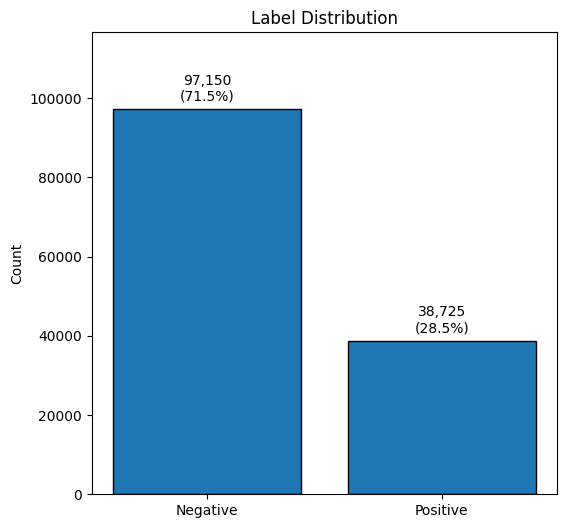

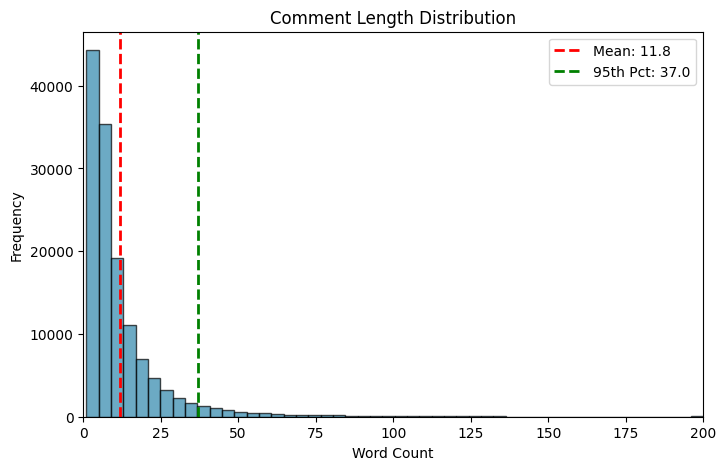

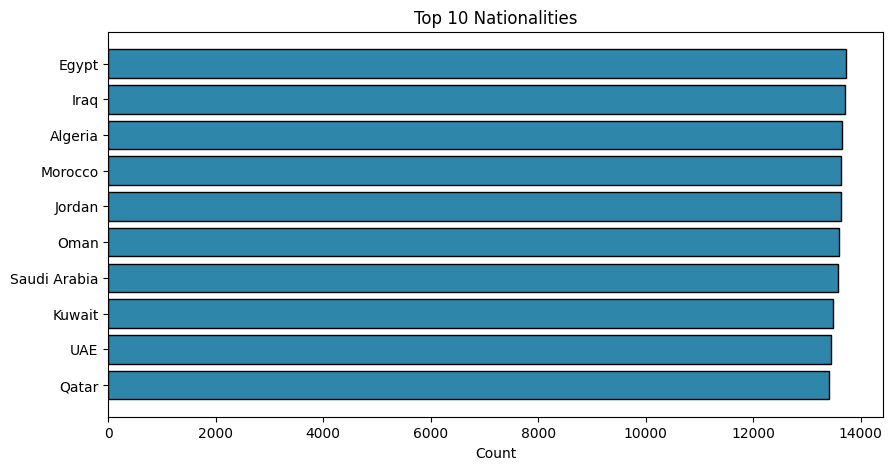

NameError: name 're' is not defined

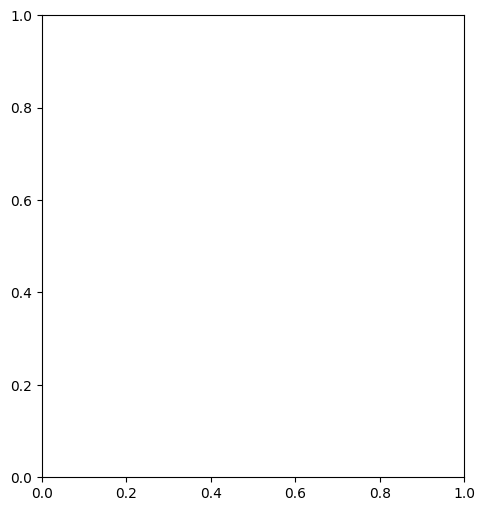

In [12]:
# Enhanced NLP Preprocessing for WordCloud (Stopwords + Normalization + Simple Stemming)
AR_STOP_WORDS = set([
    "و", "على", "من", "في", "الي", "الى", "هذا", "هذه", "التي", "الذي", "ان", "انها", "كان", "كانت",
    "عن", "مع", "كل", "يا", "ما", "هذا", "اذا", "بعد", "قبل", "عند", "او", "ام", "لقد",
    "بين", "ثم", "حتى", "لا", "لم", "لن", "ليس", "ليست", "هم", "هن", "هو", "هي", "نحن", "انت", "انتم",
    "كم", "ذا", "ذو", "ذا", "ذي", "لو", "لاسيما", "غير", "فقط", "فان", "فانها", "فانهم",
    "جد", "جدا", "ايضا", "دائما", "ابدا", "اصبح", "اضحي", "امسي", "بات", "ظل", "صار", "ليس",
    "يكون", "تكون", "تكونوا", "كانوا", "كنا", "كنتم", "كنت", "علي", "عليه", "عليها", "عليهم",
    "عليك", "عليكم", "مني", "منه", "منها", "منهم", "منك", "منكم", "فيا", "فيه", "فيها", "فيهم",
    "فيك", "فيكم", "بها", "به", "بهم", "بي", "بك", "بكم", "انه", "انها", "انهم", "اني", "انك", "انكم",
    "لكن", "لكنه", "لكنها", "لكنهم", "لكني", "لكنك", "لكنكم", "بل", "بلا", "بلى", "بس", "يعني", "اللي", "الي", "عشان",
    "ده", "دي", "دول", "يا", "اي", "ايوه", "لاء", "تمام", "ماشي", "حاجة", "حاجه", "كده", "كدا", "هيك", "شو", "ايش", "وين", "متى", "فين",
    "ال", "يا", "ان"
])

def clean_for_wordcloud(text):
    if not isinstance(text, str): return ""
    # 1. Basic Normalization (Alef, Teh Marbuta, Alef Maksura)
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    # 2. Remove Diacritics
    text = re.sub(r'[\u064B-\u0652]', '', text)
    # 3. Tokenize and Filter
    words = text.split()
    cleaned_words = []
    for w in words:
        # Strip common prefix 'al-' (ال)
        if w.startswith('ال') and len(w) > 4:
            w = w[2:]
        if w not in AR_STOP_WORDS and len(w) > 1:
            cleaned_words.append(w)
    return " ".join(cleaned_words)

plt.figure(figsize=(6, 6))
counts = df_labelled['sentiment'].value_counts()
bars = plt.bar(counts.index, counts.values, edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + len(df_labelled)*0.01, f"{yval:,}\n({yval/len(df_labelled)*100:.1f}%)", ha='center', va='bottom')
plt.title("Label Distribution")
plt.ylabel("Count")
plt.ylim(0, counts.max() * 1.2)
plt.savefig(os.path.join(IMAGE_DIR, 'fig_01_label_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# fig_02 - Comment Length Distribution
df_labelled['word_count'] = df_labelled['comment_text'].astype(str).str.split().str.len()
mean_len = df_labelled['word_count'].mean()
p95_len = df_labelled['word_count'].quantile(0.95)

plt.figure(figsize=(8, 5))
plt.hist(df_labelled['word_count'].clip(upper=200), bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_len:.1f}')
plt.axvline(p95_len, color='green', linestyle='dashed', linewidth=2, label=f'95th Pct: {p95_len:.1f}')
plt.xlim(0, 200)
plt.title("Comment Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.savefig(os.path.join(IMAGE_DIR, 'fig_02_comment_length.png'), dpi=300, bbox_inches='tight')
plt.show()

# fig_03 - Nationality Distribution
if 'nationality' in df_labelled.columns:
    plt.figure(figsize=(10, 5))
    nat_counts = df_labelled['nationality'].value_counts().head(10)
    plt.barh(nat_counts.index[::-1], nat_counts.values[::-1], color='#2E86AB', edgecolor='black')
    plt.title("Top 10 Nationalities")
    plt.xlabel("Count")
    plt.savefig(os.path.join(IMAGE_DIR, 'fig_03_nationality.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No nationality column found. Skipping fig_03.")

# fig_04 - Word Cloud
plt.figure(figsize=(12, 6))
for i, sentiment in enumerate(['Positive', 'Negative']):
    plt.subplot(1, 2, i+1)
    text = " ".join(df_labelled[df_labelled['sentiment'] == sentiment]['comment_text'].apply(clean_for_wordcloud).astype(str))
    reshaped_text = arabic_reshaper.reshape(text)
    # Remove BiDi control characters that cause bidi.algorithm to crash
    import re
    reshaped_text = re.sub(r'[\u202a-\u202e\u2066-\u2069]', '', reshaped_text)
    try:
        bidi_text = get_display(reshaped_text)
    except AssertionError:
        bidi_text = reshaped_text # Fallback
    wc = WordCloud(width=400, height=400, background_color='white', font_path='arial').generate(bidi_text)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"{sentiment} Word Cloud")
    plt.axis('off')
plt.savefig(os.path.join(IMAGE_DIR, 'fig_04_wordcloud.png'), dpi=300, bbox_inches='tight')
plt.show()

# Summary Stats
stats = df_labelled.groupby('sentiment')['word_count'].agg(['mean', 'median', 'max']).round(2)
display(stats)


## 3 · Text Preprocessing
Cleans Arabic text by removing noise, normalising characters, and stripping diacritics.

In [ ]:
import re
try:
    from pandarallel import pandarallel
    # Disabling pandarallel to prevent NameError: 're' across workers
    USE_PANDARALLEL = False
except ImportError:
    USE_PANDARALLEL = False

def clean_arabic(text):
    import re
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^\s\u0600-\u06FF\u2600-\u27BF\U00010000-\U0010FFFF]', ' ', text) # Keep Arabic, space, and emojis
    text = re.sub(r'[أإآ]', 'ا', text)
    text = text.replace('ة', 'ه').replace('ى', 'ي')
    text = re.sub(r'ـ+', '', text)
    text = re.sub(r'[\u064B-\u065F]', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

if USE_PANDARALLEL:
    df_labelled['clean_text'] = df_labelled['comment_text'].parallel_apply(clean_arabic)
else:
    tqdm.pandas()
    df_labelled['clean_text'] = df_labelled['comment_text'].progress_apply(clean_arabic)

display(df_labelled[['comment_text', 'clean_text']].head())


In [ ]:
# Save cleaned data for future use and to fulfill pipeline organization
df_labelled.to_pickle(os.path.join(PROCESSED_DATA_DIR, 'cleaned_data.pkl'))
print(f"Cleaned data saved to {os.path.join(PROCESSED_DATA_DIR, 'cleaned_data.pkl')}")


## 4 · Train / Validation / Test Split
Stratified 70/15/15 split to maintain class balance across all sets.

In [ ]:
from sklearn.model_selection import train_test_split

X = np.array(df_labelled['clean_text'].tolist())
y = df_labelled['label'].astype(int).to_numpy()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=SEED)

splits = {
    'Train': (X_train, y_train),
    'Validation': (X_val, y_val),
    'Test': (X_test, y_test)
}

rows = []
for name, (x_s, y_s) in splits.items():
    rows.append({
        'Split': name,
        'Total': len(y_s),
        'Positive': (y_s == 1).sum(),
        'Negative': (y_s == 0).sum()
    })

split_df = pd.DataFrame(rows)
display(split_df)


## 5 · Tokenization (AraBERT)
Prepares the data for AraBERT using a custom PyTorch Dataset and DataLoaders.

In [ ]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

MODEL_NAME = "aubmindlab/bert-base-arabertv02"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ArabicSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ArabicSentimentDataset(X_train, y_train, tokenizer)
val_dataset = ArabicSentimentDataset(X_val, y_val, tokenizer)
test_dataset = ArabicSentimentDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# Decode sample
sample = train_dataset[0]
print("Sample Decode:\n", tokenizer.decode(sample['input_ids'], skip_special_tokens=True))


## 6 · Model Definition — AraBERT-BiLSTM
Defines the AraBERT encoder combined with a BiLSTM classification head.

In [ ]:
import torch.nn as nn
from transformers import AutoModel

class ArabertBiLSTM(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        
        # Unfreeze all layers for full fine-tuning
        for param in self.bert.parameters():
            param.requires_grad = True
                    
        self.bilstm = nn.LSTM(input_size=768, hidden_size=256, num_layers=2, 
                              dropout=0.3, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(512, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # We pass the full sequence to BiLSTM
        lstm_out, _ = self.bilstm(bert_output.last_hidden_state)
        # Take the CLS token representation (index 0) from LSTM output
        cls_out = lstm_out[:, 0, :]
        x = self.dropout(cls_out)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

model = ArabertBiLSTM().to(device)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {trainable_params:,}")


## 7 · Training
Trains the model using AdamW with cosine decay, class weights, and early stopping.

In [ ]:
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import torch.nn.functional as F

# --- Anti-Overfitting Strategy: Focal Loss + Differential LR + Warmup ---

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
criterion = FocalLoss(alpha=torch.tensor(class_weights, dtype=torch.float).to(device))

# 1. Differential Learning Rates: BERT needs low LR, custom head can handle higher LR
optimizer_grouped_parameters = [
    {'params': [p for n, p in model.bert.named_parameters()], 'lr': 1e-5}, # Lower for BERT
    {'params': [p for n, p in model.named_parameters() if 'bert' not in n], 'lr': 5e-5} # Higher for Head
]

optimizer = AdamW(optimizer_grouped_parameters, weight_decay=0.05) # Increased weight decay

EPOCHS = 1
total_steps = len(train_loader) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

best_f1 = 0
patience = 3
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # 2. Layer-wise Warmup: Freeze BERT for first epoch to let the Head stabilize
    if epoch == 0:
        for param in model.bert.parameters():
            param.requires_grad = False
        print("Epoch 1: BERT layers frozen for Head stabilization")
    elif epoch == 1:
        for param in model.bert.parameters():
            param.requires_grad = True
        print("Epoch 2: BERT layers unfrozen for fine-tuning")

    model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient Clipping to prevent exploding gradients in LSTM
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    model.eval()
    val_loss, val_preds, val_true = 0, [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(labels.cpu().numpy())
            
    val_acc = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds, average='macro')
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")
    
    # 3. Save best model based on Val Loss or F1 (monitoring both is safer)
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'best_model.pt'))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


## 8 · Evaluation on Test Set
Evaluates the best model on the unseen test set, producing confusion matrix and ROC curves.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'best_model.pt'), map_location=device))
model.eval()

test_preds = []
test_probs = []
test_true = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids, attention_mask)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        
        test_probs.extend(probs)
        test_preds.extend(preds)
        test_true.extend(labels.cpu().numpy())

print(classification_report(test_true, test_preds, target_names=['Negative', 'Positive']))

acc = accuracy_score(test_true, test_preds)
macro_f1 = f1_score(test_true, test_preds, average='macro')
weighted_f1 = f1_score(test_true, test_preds, average='weighted')
auc = roc_auc_score(test_true, test_probs)

results = [{'Model': 'AraBERT-BiLSTM', 'Accuracy': f"{acc*100:.2f}%", 'Macro-F1': f"{macro_f1*100:.2f}%", 'Weighted-F1': f"{weighted_f1*100:.2f}%", 'AUC': f"{auc*100:.2f}%"}]

# fig_06 - Confusion Matrix
cm = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 6))
sns.heatmap(cm_norm, annot=np.array([f"{val:.2f}\n({count})" for val, count in zip(cm_norm.flatten(), cm.flatten())]).reshape(2, 2), 
            fmt='', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(IMAGE_DIR, 'fig_06_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# fig_07 - ROC Curve
fpr, tpr, _ = roc_curve(test_true, test_probs)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='#2E86AB', lw=2, label=f'AraBERT-BiLSTM (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.savefig(os.path.join(IMAGE_DIR, 'fig_07_roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()


## 9 · Baseline Comparisons
Trains lightweight ML baselines for comparison against the AraBERT-BiLSTM model.

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Initialize the results list so .append() works
results = []

# TF-IDF Setup
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# --- LR Baseline ---
# Added n_jobs=-1 to use all CPU cores for faster training
lr = LogisticRegression(max_iter=500, n_jobs=-1)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)

results.append({
    'Model': 'TF-IDF + LR', 
    'Accuracy': f"{accuracy_score(y_test, lr_preds)*100:.2f}%", 
    'Macro-F1': f"{f1_score(y_test, lr_preds, average='macro')*100:.2f}%",
    'Weighted-F1': f"{f1_score(y_test, lr_preds, average='weighted')*100:.2f}%",
    'AUC': f"{roc_auc_score(y_test, lr.predict_proba(X_test_tfidf)[:, 1])*100:.2f}%"
})

# --- SVM Baseline (Optimized) ---
# We use LinearSVC because standard SVC is too slow for 130k samples.
# CalibratedClassifierCV allows us to get 'predict_proba' for the AUC score.
base_svm = LinearSVC(dual=False, max_iter=1000)
svm = CalibratedClassifierCV(base_svm, cv=3) 
svm.fit(X_train_tfidf, y_train)
svm_preds = svm.predict(X_test_tfidf)

results.append({
    'Model': 'TF-IDF + SVM', 
    'Accuracy': f"{accuracy_score(y_test, svm_preds)*100:.2f}%", 
    'Macro-F1': f"{f1_score(y_test, svm_preds, average='macro')*100:.2f}%",
    'Weighted-F1': f"{f1_score(y_test, svm_preds, average='weighted')*100:.2f}%",
    'AUC': f"{roc_auc_score(y_test, svm.predict_proba(X_test_tfidf)[:, 1])*100:.2f}%"
})

# Display Results
results_df = pd.DataFrame(results)
display(results_df)

## 10 · Error Analysis
Examines misclassified examples to understand model weaknesses (e.g., sarcasm, dialects).

### Error Categorization
- **Code-switching / Franco-Arabic:** Comments using Latin characters or English words mixed with Arabic.
- **Dialects & Colloquialisms:** Heavy use of Maghrebi, Egyptian, or Gulf terms that AraBERT (trained on MSA) struggles with.
- **Sarcasm:** Positive phrasing with a negative intent, requiring deep contextual understanding.

In [ ]:
test_true = np.array(test_true)
test_preds = np.array(test_preds)

errors = X_test[test_true != test_preds]
true_err = test_true[test_true != test_preds]
pred_err = test_preds[test_true != test_preds]

fp_idx = np.where((true_err == 0) & (pred_err == 1))[0]
fn_idx = np.where((true_err == 1) & (pred_err == 0))[0]

sample_fp = fp_idx[:10] if len(fp_idx) >= 10 else fp_idx
sample_fn = fn_idx[:10] if len(fn_idx) >= 10 else fn_idx

err_indices = np.concatenate([sample_fp, sample_fn])

error_df = pd.DataFrame({
    'comment': [errors[i] for i in err_indices],
    'true_label': [true_err[i] for i in err_indices],
    'predicted_label': [pred_err[i] for i in err_indices]
})

display(error_df)


## 11 · Save Outputs for Paper
Exports the results table for LaTeX integration.

In [ ]:
# Collect all figure paths
figures = [
    os.path.join(IMAGE_DIR, 'fig_01_label_distribution.png'),
    os.path.join(IMAGE_DIR, 'fig_02_comment_length.png'),
    os.path.join(IMAGE_DIR, 'fig_03_nationality.png'),
    os.path.join(IMAGE_DIR, 'fig_04_wordcloud.png'),
    os.path.join(IMAGE_DIR, 'fig_05_training_curves.png'),
    os.path.join(IMAGE_DIR, 'fig_06_confusion_matrix.png'),
    os.path.join(IMAGE_DIR, 'fig_07_roc_curve.png'),
]

# Save results table as CSV for LaTeX import
results_df.to_csv(os.path.join(RESULT_DIR, 'results_table.csv'), index=False)

# Print LaTeX-formatted table directly
print(results_df.to_latex(index=False))
